In [1]:
# Import libraries for file handling, data processing, ML
import zipfile
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Extract the UTKFace archive
import zipfile
zip_path = "/content/archive (2).zip"
extract_to = "/content/utkface_raw"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

In [4]:
# Merge the two folders inside the archive into one folder
folder1 = "/content/utkface_raw/UTKFace"
folder2 = "/content/utkface_raw/crop_part1"
merged_folder = "/content/merged_faces"

os.makedirs(merged_folder, exist_ok=True)

for folder in [folder1, folder2]:
    for img in glob(os.path.join(folder, "*.jpg")):
        shutil.copy(img, merged_folder)

In [7]:
# Reduce Dataset to 10,000 Images
import random
reduced_folder = "/content/reduced_faces"
os.makedirs(reduced_folder, exist_ok=True)

all_images = [os.path.join(merged_folder, f) for f in os.listdir(merged_folder) if f.endswith(".jpg")]
selected = random.sample(all_images, 10000)

for img in selected:
    shutil.copy(img, reduced_folder)

In [8]:
# Create a dataframe with image paths and age labels
paths = glob(os.path.join(reduced_folder, "*.jpg"))
ages = [int(os.path.basename(p).split("_")[0]) for p in paths]

df = pd.DataFrame({"image_path": paths, "age": ages})

In [9]:
# Split data into train, validation, and test sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [10]:
# Set up image generators with augmentation for training
img_size = (128, 128)

train_gen = ImageDataGenerator(rescale=1/255.0)
val_gen = ImageDataGenerator(rescale=1/255.0)

train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="age",
    target_size=img_size,
    class_mode="raw",
    batch_size=32
)

val_data = val_gen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="age",
    target_size=img_size,
    class_mode="raw",
    batch_size=32
)


Found 8000 validated image filenames.
Found 2000 validated image filenames.


In [15]:
# Build a simple CNN for age regression
from tensorflow.keras.layers import MaxPool2D

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPool2D(),
    Conv2D(64, (3,3), activation="relu"),
    MaxPool2D(),
    Conv2D(128, (3,3), activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Train the CNN with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks = [early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - loss: 505.3389 - mae: 17.2658 - val_loss: 325.4962 - val_mae: 13.7838
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - loss: 302.1533 - mae: 13.3494 - val_loss: 200.8628 - val_mae: 10.8705
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - loss: 208.6405 - mae: 10.9684 - val_loss: 171.0934 - val_mae: 9.8041
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - loss: 183.4887 - mae: 10.2406 - val_loss: 155.6056 - val_mae: 9.2266
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - loss: 154.4436 - mae: 9.4281 - val_loss: 168.2334 - val_mae: 10.3082
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - loss: 136.1972 - mae: 8.8220 - val_loss: 139.6691 - val_mae: 8.5894
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - loss: 130.9999 - mae: 8.5417 - val_loss: 109.7602 - val_mae: 7.8699
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - loss: 114.9943 - mae: 8.0758 - val_loss: 108.6074 - val_mae: 7.8842
Epoch 9/2

In [17]:
# Evaluate model performance on the test set
test_loss, test_mae = model.evaluate(val_data)
print("Test MAE:", test_mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - loss: 91.6045 - mae: 6.9630
Test MAE: 7.109091281890869


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


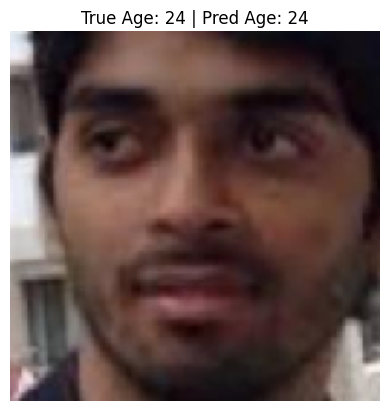

In [20]:
# Display sample predictions
def show_sample_predictions(df, num=1):
    sample = df.sample(num)
    for _, row in sample.iterrows():
        img = tf.keras.preprocessing.image.load_img(row["image_path"], target_size=img_size)
        img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        pred = model.predict(np.expand_dims(img_arr, axis=0))[0][0]
        plt.imshow(img_arr)
        plt.title(f"True Age: {row['age']} | Pred Age: {int(pred)}")
        plt.axis("off")
        plt.show()

show_sample_predictions(val_df, num=1)

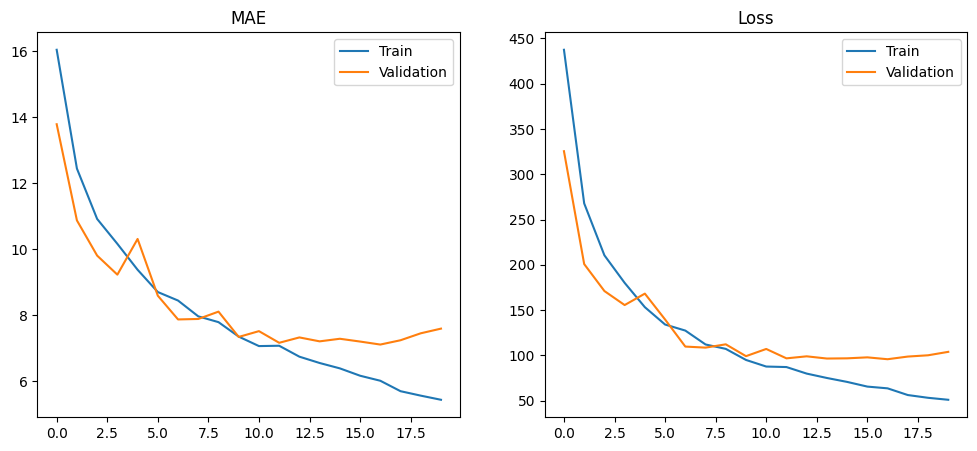

In [21]:

# Plot training loss and MAE
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title("MAE")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


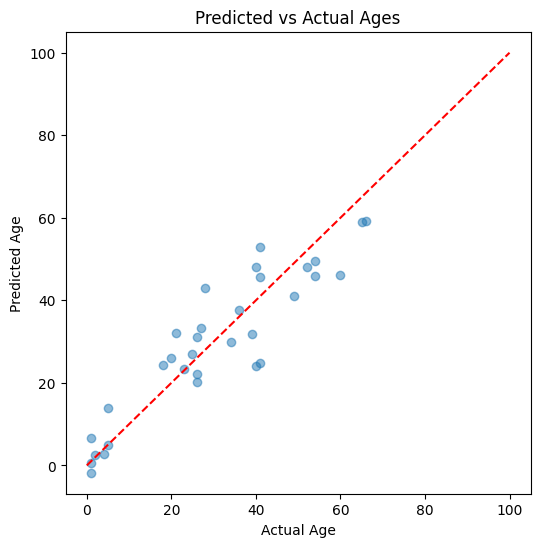

In [22]:
# Predicted vs Actual scatter plot for validation set
val_images, val_labels = next(iter(val_data))
preds = model.predict(val_images)

plt.figure(figsize=(6,6))
plt.scatter(val_labels, preds, alpha=0.5)
plt.plot([0, 100], [0, 100], color='red', linestyle='--') # Perfect prediction line
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Actual Ages")
plt.show()